<a href="https://colab.research.google.com/github/Sharif2138/African-Language-Health-QA-Challenge/blob/main/EDA_and_Exp1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multilingual Health QA Challenge

Exploratory Data Analysis (EDA)

Goals:
- Understand dataset structure
- Detect duplicates
- Detect leakage
- Understand language distribution
- Analyze sequence lengths
- Estimate tokenizer requirements
- Inform model selection

In [ ]:
#mount drive to access our datasets and storage of models and plots
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [ ]:
#import all necessary libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from transformers import AutoTokenizer

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 500)

print("Libraries Loaded")

Libraries Loaded


# Load Dataset

In [ ]:
#load datasets into memory as pandas dataframes
train = pd.read_csv("/content/drive/MyDrive/datasets/Train.csv")
val = pd.read_csv("/content/drive/MyDrive/datasets/Val.csv")
test = pd.read_csv("/content/drive/MyDrive/datasets/Test.csv")

#check shape of data, ie number of samples and columns
print("Train Shape:", train.shape)
print("Validation Shape:", val.shape)
print("Test Shape:", test.shape)

Train Shape: (29815, 4)
Validation Shape: (6686, 4)
Test Shape: (2618, 3)


In [ ]:
#visualise our dataset through some samples
train.head()

,ID,input,output,subset
0,ID_TR_Aka_Gha_A3B1799D,"Ɔkwan bɛn so na mmabunbɛtumi aboa wɔn mfɛfoɔ a nsa anaa nnubɔne ama wɔayɛ wɔn ayayadeɛ? Yei bi ne sɛnea wɔbɛkyekye wɔn werɛ, sɛnea wɔbɛboa wɔn ma wɔanya mmoa firi nnwumakuo a ɛfata hɔ, ne sɛnea wɔbɛsiw afɔbu suban ne nsɛm a nkurɔfoɔ de gu oyarefoɔ no so no kwan.","Mmabun betumi aboa atipɛnfo a ebia nsa anaa nnubɔne ama wɔayɛ wɔn ayayadeɛ so denam: Nkate fam mmoa a wɔde bɛma na wɔagye wɔn nkate atom a wɔremmu atɛn anaasɛ wɔmfa asodi nto wɔn so. Wɔn a wɔbɛhyɛ wɔn nkuran ma wɔakɔhwehwɛ ayaresa na wɔanya mmoa nnwuma te sɛ afotu, telefon a wɔde frɛ nkurɔfo wɔ ɔhaw mu, anaa ahyehyɛde ahorow a wɔkamfo nkurɔfo. Boa a wɔbɛboa wɔn ma wɔafa akwan horow a wɔbɛfa so abɔ amanneɛ, a nea ɛka ho ne sɛ wɔbɛkɔ mmarahyɛ baguafo nkyɛn anaasɛ wɔbɛhwehwɛ mmara kwan so mmoa ...",Aka_Gha
1,ID_TR_Aka_Gha_1C80317F,"Edinnsiananmu bɛn na nnipa a ɛsono wɔn bɔbeasu taa de di dwuma, na yɛbɛyɛ dɛn ahwɛ ahu sɛ yɛde redi dwuma yiye?","Wɔ Ghana mu no, amanmmra no gye binary gender nkutoo tom a she/he edinnsiananmu nkutoo na ɛka ho",Aka_Gha
2,ID_TR_Aka_Gha_06671AD1,Ɔkwan bɛn so na ɔbarima ne ɔbea nna a wɔtwe wɔn ho fi ho anaa nna mu adwumadi a wɔtwentwɛn so no boa ma asiane so tew?,"Sɛ wɔtwe wɔn ho fi nna mu anaasɛ wɔtwentwɛn wɔn nan ase a, ɛboa ma asiane nso tew denam asiane a ɛwɔ STI ne HIV a ɛbata nna ho a woyi fi hɔ anaasɛ wɔkyɛ so. Sɛ obi twe ne ho fi ho a, ɛkyerɛ sɛ ɔbɛkwati nna mu dwumadi biara, a ɔbarima ne ɔbea nna a ɔde ne ho hyɛ ɔbarima ne ɔbea nna mu, awotwaa mu, ne anom nna ka ho. Sɛ wopaw sɛ wobɛtwe wo ho afi nna ho anaasɛ wobɛtwentwɛn nna mu kosi sɛ wubesiesie wo ho na wo ne ɔhokafo a onni ɔbarima ne ɔbea nna mu yare ne HIV nni ɔyere biako ntam abusuabɔ s...",Aka_Gha
3,ID_TR_Aka_Gha_BDD640FB,"Dɛn ne aduru a wodi si nyisɛn ano ntɛm ntɛm, na ɛyɛ adwuma sɛn?","Aduru a wodi si nyisɛn ano ntɛm ntɛm (Emergency contraception (EC)) kyerɛ akwan a wɔfa so siw nyinsɛn ano wɔ nna a wɔammɔ ho ban, nyinsɛn ano a entumi nyɛ adwuma yiye, anaa nna mu ɔbrasɛe akyi. EC yɛ adwuma denam ovulation a esiw ano anaasɛ ɛkyɛ, ɛwo a wɔde mmadwoa nyinsɛn, anaasɛ ɛwo a wɔahyɛ no ma a wɔde hyɛ awotwaa mu, a egyina ɔkwan pɔtee a wɔfa so yɛ ne bere a wɔde ma so.",Aka_Gha
4,ID_TR_Aka_Gha_46685257,"Hu sɛnea ɛyɛ den sɛ wubehu bɔbea mu basabasayɔ (GBV) na woayɛ ho biribi, na si hia a ɛho hia sɛ wohwehwɛ mmoa so dua.","Ɛnyɛ mmerɛw bere nyinaa sɛ wubehu bɔbea mu basabasayɔ (GBV), nanso kae sɛ, mmoa a wobɛhwehwɛ no yɛ ahoɔden ho sɛnkyerɛnne, na ɛnyɛ mmerɛwyɛ.",Aka_Gha


In [ ]:
#visualise the columns in our dataset
print(train.columns)

Index(['ID', 'input', 'output', 'subset'], dtype='object')


In [ ]:
#check for datatypes and missing values
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29815 entries, 0 to 29814
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   ID      29815 non-null  object
 1   input   29815 non-null  object
 2   output  29815 non-null  object
 3   subset  29815 non-null  object
dtypes: object(4)
memory usage: 931.8+ KB


# Missing Values Analysis

In [ ]:
#better check for any missing values
print("=== missing train values ===")
print(train.isnull().sum())
print("=== missing val values  ===")
print(val.isnull().sum())
print("=== missing test values ===")
print(test.isnull().sum())

=== missing train values ===
ID        0
input     0
output    0
subset    0
dtype: int64
=== missing val values  ===
ID        0
input     0
output    0
subset    0
dtype: int64
=== missing test values ===
ID        0
input     0
subset    0
dtype: int64


# Language Distribution

In [ ]:
#check for imbalances within our data
#print frequency counts per langauage
train["subset"].value_counts()

,count
subset,
Eng_Uga,7624
Aka_Gha,4455
Eng_Gha,4443
Eng_Eth,3915
Lug_Uga,3383
Eng_Ken,2080
Swa_Ken,2070
Amh_Eth,1845


In [ ]:
#turning our frequency counts into percentages
train["subset"].value_counts(normalize=True) * 100

,proportion
subset,
Eng_Uga,25.571021
Aka_Gha,14.942143
Eng_Gha,14.901895
Eng_Eth,13.130974
Lug_Uga,11.346638
Eng_Ken,6.976354
Swa_Ken,6.942814
Amh_Eth,6.188160


saved plot successfully


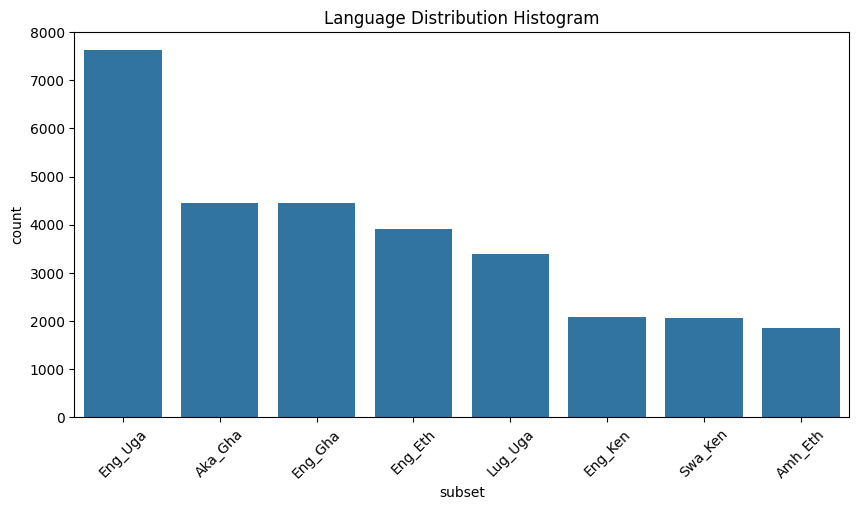

In [ ]:
#visualise our langauge distribution on a plot to better analyse imbalances
plt.figure(figsize=(10,5))

sns.countplot(
    data=train,
    x="subset",
    order=train["subset"].value_counts().index
)

plt.xticks(rotation=45)
plt.title("Language Distribution Histogram")
plt.savefig("/content/drive/MyDrive/plots/langauge distribution histogram", dpi=300, bbox_inches='tight')
print("saved plot successfully")
plt.show()

# Question Length Analysis

In [ ]:
#create a new column question_chars to store the nuber of characters per question
train["question_chars"] = train["input"].astype(str).apply(len)

#visualise the changes
train.head()

,ID,input,output,subset,question_chars
0,ID_TR_Aka_Gha_A3B1799D,"Ɔkwan bɛn so na mmabunbɛtumi aboa wɔn mfɛfoɔ a nsa anaa nnubɔne ama wɔayɛ wɔn ayayadeɛ? Yei bi ne sɛnea wɔbɛkyekye wɔn werɛ, sɛnea wɔbɛboa wɔn ma wɔanya mmoa firi nnwumakuo a ɛfata hɔ, ne sɛnea wɔbɛsiw afɔbu suban ne nsɛm a nkurɔfoɔ de gu oyarefoɔ no so no kwan.","Mmabun betumi aboa atipɛnfo a ebia nsa anaa nnubɔne ama wɔayɛ wɔn ayayadeɛ so denam: Nkate fam mmoa a wɔde bɛma na wɔagye wɔn nkate atom a wɔremmu atɛn anaasɛ wɔmfa asodi nto wɔn so. Wɔn a wɔbɛhyɛ wɔn nkuran ma wɔakɔhwehwɛ ayaresa na wɔanya mmoa nnwuma te sɛ afotu, telefon a wɔde frɛ nkurɔfo wɔ ɔhaw mu, anaa ahyehyɛde ahorow a wɔkamfo nkurɔfo. Boa a wɔbɛboa wɔn ma wɔafa akwan horow a wɔbɛfa so abɔ amanneɛ, a nea ɛka ho ne sɛ wɔbɛkɔ mmarahyɛ baguafo nkyɛn anaasɛ wɔbɛhwehwɛ mmara kwan so mmoa ...",Aka_Gha,262
1,ID_TR_Aka_Gha_1C80317F,"Edinnsiananmu bɛn na nnipa a ɛsono wɔn bɔbeasu taa de di dwuma, na yɛbɛyɛ dɛn ahwɛ ahu sɛ yɛde redi dwuma yiye?","Wɔ Ghana mu no, amanmmra no gye binary gender nkutoo tom a she/he edinnsiananmu nkutoo na ɛka ho",Aka_Gha,111
2,ID_TR_Aka_Gha_06671AD1,Ɔkwan bɛn so na ɔbarima ne ɔbea nna a wɔtwe wɔn ho fi ho anaa nna mu adwumadi a wɔtwentwɛn so no boa ma asiane so tew?,"Sɛ wɔtwe wɔn ho fi nna mu anaasɛ wɔtwentwɛn wɔn nan ase a, ɛboa ma asiane nso tew denam asiane a ɛwɔ STI ne HIV a ɛbata nna ho a woyi fi hɔ anaasɛ wɔkyɛ so. Sɛ obi twe ne ho fi ho a, ɛkyerɛ sɛ ɔbɛkwati nna mu dwumadi biara, a ɔbarima ne ɔbea nna a ɔde ne ho hyɛ ɔbarima ne ɔbea nna mu, awotwaa mu, ne anom nna ka ho. Sɛ wopaw sɛ wobɛtwe wo ho afi nna ho anaasɛ wobɛtwentwɛn nna mu kosi sɛ wubesiesie wo ho na wo ne ɔhokafo a onni ɔbarima ne ɔbea nna mu yare ne HIV nni ɔyere biako ntam abusuabɔ s...",Aka_Gha,118
3,ID_TR_Aka_Gha_BDD640FB,"Dɛn ne aduru a wodi si nyisɛn ano ntɛm ntɛm, na ɛyɛ adwuma sɛn?","Aduru a wodi si nyisɛn ano ntɛm ntɛm (Emergency contraception (EC)) kyerɛ akwan a wɔfa so siw nyinsɛn ano wɔ nna a wɔammɔ ho ban, nyinsɛn ano a entumi nyɛ adwuma yiye, anaa nna mu ɔbrasɛe akyi. EC yɛ adwuma denam ovulation a esiw ano anaasɛ ɛkyɛ, ɛwo a wɔde mmadwoa nyinsɛn, anaasɛ ɛwo a wɔahyɛ no ma a wɔde hyɛ awotwaa mu, a egyina ɔkwan pɔtee a wɔfa so yɛ ne bere a wɔde ma so.",Aka_Gha,63
4,ID_TR_Aka_Gha_46685257,"Hu sɛnea ɛyɛ den sɛ wubehu bɔbea mu basabasayɔ (GBV) na woayɛ ho biribi, na si hia a ɛho hia sɛ wohwehwɛ mmoa so dua.","Ɛnyɛ mmerɛw bere nyinaa sɛ wubehu bɔbea mu basabasayɔ (GBV), nanso kae sɛ, mmoa a wobɛhwehwɛ no yɛ ahoɔden ho sɛnkyerɛnne, na ɛnyɛ mmerɛwyɛ.",Aka_Gha,117


In [ ]:
#check the distribution of the question lengths
train["question_chars"].describe()

,question_chars
count,29815.000000
mean,89.915143
std,50.838964
min,1.000000
25%,55.000000
50%,78.000000
75%,111.000000
max,520.000000


saved plot successfully


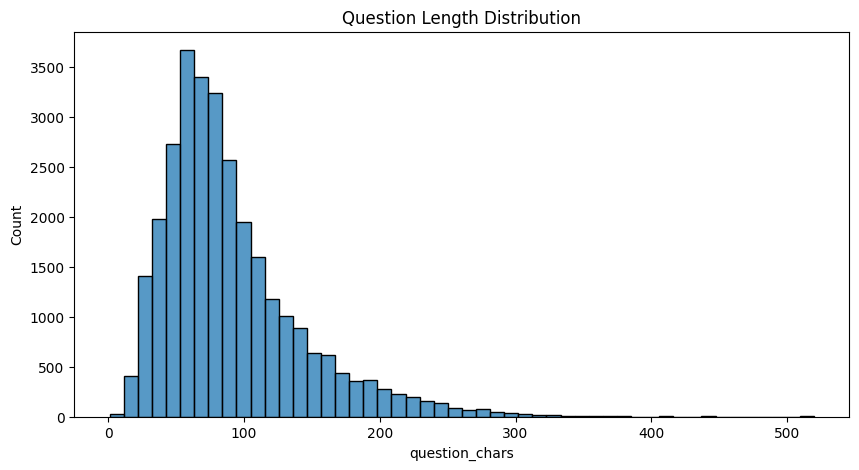

In [ ]:
#visualise the distrubtion of the question characters
plt.figure(figsize=(10,5))

sns.histplot(
    train["question_chars"],
    bins=50
)

plt.title("Question Length Distribution")
plt.savefig("/content/drive/MyDrive/plots/Question Length distribution histogram", dpi=300, bbox_inches='tight')
print("saved plot successfully")
plt.show()

In [ ]:
##create a new column question_chars to store the nuber of words per question
train["question_words"] = (
    train["input"]
    .astype(str)
    .apply(lambda x: len(x.split()))
)

train.head()

,ID,input,output,subset,question_chars,question_words
0,ID_TR_Aka_Gha_A3B1799D,"Ɔkwan bɛn so na mmabunbɛtumi aboa wɔn mfɛfoɔ a nsa anaa nnubɔne ama wɔayɛ wɔn ayayadeɛ? Yei bi ne sɛnea wɔbɛkyekye wɔn werɛ, sɛnea wɔbɛboa wɔn ma wɔanya mmoa firi nnwumakuo a ɛfata hɔ, ne sɛnea wɔbɛsiw afɔbu suban ne nsɛm a nkurɔfoɔ de gu oyarefoɔ no so no kwan.","Mmabun betumi aboa atipɛnfo a ebia nsa anaa nnubɔne ama wɔayɛ wɔn ayayadeɛ so denam: Nkate fam mmoa a wɔde bɛma na wɔagye wɔn nkate atom a wɔremmu atɛn anaasɛ wɔmfa asodi nto wɔn so. Wɔn a wɔbɛhyɛ wɔn nkuran ma wɔakɔhwehwɛ ayaresa na wɔanya mmoa nnwuma te sɛ afotu, telefon a wɔde frɛ nkurɔfo wɔ ɔhaw mu, anaa ahyehyɛde ahorow a wɔkamfo nkurɔfo. Boa a wɔbɛboa wɔn ma wɔafa akwan horow a wɔbɛfa so abɔ amanneɛ, a nea ɛka ho ne sɛ wɔbɛkɔ mmarahyɛ baguafo nkyɛn anaasɛ wɔbɛhwehwɛ mmara kwan so mmoa ...",Aka_Gha,262,50
1,ID_TR_Aka_Gha_1C80317F,"Edinnsiananmu bɛn na nnipa a ɛsono wɔn bɔbeasu taa de di dwuma, na yɛbɛyɛ dɛn ahwɛ ahu sɛ yɛde redi dwuma yiye?","Wɔ Ghana mu no, amanmmra no gye binary gender nkutoo tom a she/he edinnsiananmu nkutoo na ɛka ho",Aka_Gha,111,22
2,ID_TR_Aka_Gha_06671AD1,Ɔkwan bɛn so na ɔbarima ne ɔbea nna a wɔtwe wɔn ho fi ho anaa nna mu adwumadi a wɔtwentwɛn so no boa ma asiane so tew?,"Sɛ wɔtwe wɔn ho fi nna mu anaasɛ wɔtwentwɛn wɔn nan ase a, ɛboa ma asiane nso tew denam asiane a ɛwɔ STI ne HIV a ɛbata nna ho a woyi fi hɔ anaasɛ wɔkyɛ so. Sɛ obi twe ne ho fi ho a, ɛkyerɛ sɛ ɔbɛkwati nna mu dwumadi biara, a ɔbarima ne ɔbea nna a ɔde ne ho hyɛ ɔbarima ne ɔbea nna mu, awotwaa mu, ne anom nna ka ho. Sɛ wopaw sɛ wobɛtwe wo ho afi nna ho anaasɛ wobɛtwentwɛn nna mu kosi sɛ wubesiesie wo ho na wo ne ɔhokafo a onni ɔbarima ne ɔbea nna mu yare ne HIV nni ɔyere biako ntam abusuabɔ s...",Aka_Gha,118,27
3,ID_TR_Aka_Gha_BDD640FB,"Dɛn ne aduru a wodi si nyisɛn ano ntɛm ntɛm, na ɛyɛ adwuma sɛn?","Aduru a wodi si nyisɛn ano ntɛm ntɛm (Emergency contraception (EC)) kyerɛ akwan a wɔfa so siw nyinsɛn ano wɔ nna a wɔammɔ ho ban, nyinsɛn ano a entumi nyɛ adwuma yiye, anaa nna mu ɔbrasɛe akyi. EC yɛ adwuma denam ovulation a esiw ano anaasɛ ɛkyɛ, ɛwo a wɔde mmadwoa nyinsɛn, anaasɛ ɛwo a wɔahyɛ no ma a wɔde hyɛ awotwaa mu, a egyina ɔkwan pɔtee a wɔfa so yɛ ne bere a wɔde ma so.",Aka_Gha,63,14
4,ID_TR_Aka_Gha_46685257,"Hu sɛnea ɛyɛ den sɛ wubehu bɔbea mu basabasayɔ (GBV) na woayɛ ho biribi, na si hia a ɛho hia sɛ wohwehwɛ mmoa so dua.","Ɛnyɛ mmerɛw bere nyinaa sɛ wubehu bɔbea mu basabasayɔ (GBV), nanso kae sɛ, mmoa a wobɛhwehwɛ no yɛ ahoɔden ho sɛnkyerɛnne, na ɛnyɛ mmerɛwyɛ.",Aka_Gha,117,25


In [ ]:
##check the distribution of the question lengths
train["question_words"].describe()

,question_words
count,29815.000000
mean,15.138588
std,9.098043
min,0.000000
25%,9.000000
50%,13.000000
75%,18.000000
max,83.000000


saved plot successfully


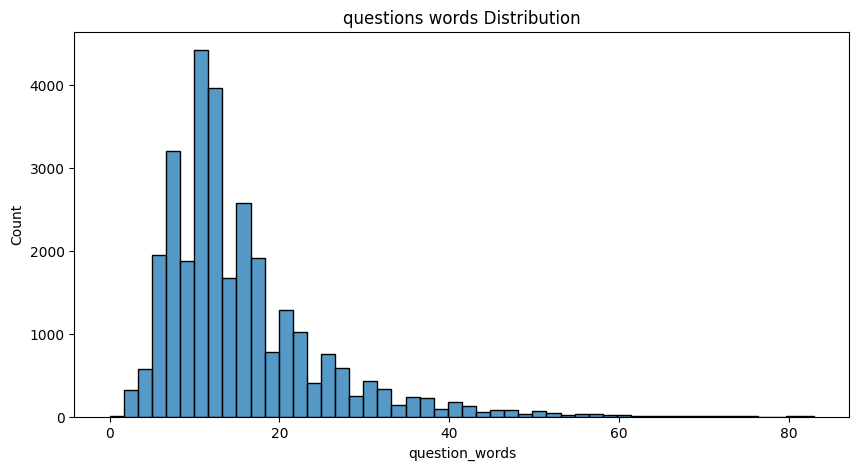

In [ ]:
#visualise the distrubtion of the question words
plt.figure(figsize=(10,5))

sns.histplot(
    train["question_words"],
    bins=50
)

plt.title("questions words Distribution")
plt.savefig("/content/drive/MyDrive/plots/Question words distribution histogram", dpi=300, bbox_inches='tight')
print("saved plot successfully")
plt.show()

# Answer Length Analysis

In [ ]:
#create a new column question_chars to store the nuber of characters per question
train["answer_chars"] = train["output"].astype(str).apply(len)

train.head()

,ID,input,output,subset,question_chars,question_words,answer_chars
0,ID_TR_Aka_Gha_A3B1799D,"Ɔkwan bɛn so na mmabunbɛtumi aboa wɔn mfɛfoɔ a nsa anaa nnubɔne ama wɔayɛ wɔn ayayadeɛ? Yei bi ne sɛnea wɔbɛkyekye wɔn werɛ, sɛnea wɔbɛboa wɔn ma wɔanya mmoa firi nnwumakuo a ɛfata hɔ, ne sɛnea wɔbɛsiw afɔbu suban ne nsɛm a nkurɔfoɔ de gu oyarefoɔ no so no kwan.","Mmabun betumi aboa atipɛnfo a ebia nsa anaa nnubɔne ama wɔayɛ wɔn ayayadeɛ so denam: Nkate fam mmoa a wɔde bɛma na wɔagye wɔn nkate atom a wɔremmu atɛn anaasɛ wɔmfa asodi nto wɔn so. Wɔn a wɔbɛhyɛ wɔn nkuran ma wɔakɔhwehwɛ ayaresa na wɔanya mmoa nnwuma te sɛ afotu, telefon a wɔde frɛ nkurɔfo wɔ ɔhaw mu, anaa ahyehyɛde ahorow a wɔkamfo nkurɔfo. Boa a wɔbɛboa wɔn ma wɔafa akwan horow a wɔbɛfa so abɔ amanneɛ, a nea ɛka ho ne sɛ wɔbɛkɔ mmarahyɛ baguafo nkyɛn anaasɛ wɔbɛhwehwɛ mmara kwan so mmoa ...",Aka_Gha,262,50,796
1,ID_TR_Aka_Gha_1C80317F,"Edinnsiananmu bɛn na nnipa a ɛsono wɔn bɔbeasu taa de di dwuma, na yɛbɛyɛ dɛn ahwɛ ahu sɛ yɛde redi dwuma yiye?","Wɔ Ghana mu no, amanmmra no gye binary gender nkutoo tom a she/he edinnsiananmu nkutoo na ɛka ho",Aka_Gha,111,22,96
2,ID_TR_Aka_Gha_06671AD1,Ɔkwan bɛn so na ɔbarima ne ɔbea nna a wɔtwe wɔn ho fi ho anaa nna mu adwumadi a wɔtwentwɛn so no boa ma asiane so tew?,"Sɛ wɔtwe wɔn ho fi nna mu anaasɛ wɔtwentwɛn wɔn nan ase a, ɛboa ma asiane nso tew denam asiane a ɛwɔ STI ne HIV a ɛbata nna ho a woyi fi hɔ anaasɛ wɔkyɛ so. Sɛ obi twe ne ho fi ho a, ɛkyerɛ sɛ ɔbɛkwati nna mu dwumadi biara, a ɔbarima ne ɔbea nna a ɔde ne ho hyɛ ɔbarima ne ɔbea nna mu, awotwaa mu, ne anom nna ka ho. Sɛ wopaw sɛ wobɛtwe wo ho afi nna ho anaasɛ wobɛtwentwɛn nna mu kosi sɛ wubesiesie wo ho na wo ne ɔhokafo a onni ɔbarima ne ɔbea nna mu yare ne HIV nni ɔyere biako ntam abusuabɔ s...",Aka_Gha,118,27,717
3,ID_TR_Aka_Gha_BDD640FB,"Dɛn ne aduru a wodi si nyisɛn ano ntɛm ntɛm, na ɛyɛ adwuma sɛn?","Aduru a wodi si nyisɛn ano ntɛm ntɛm (Emergency contraception (EC)) kyerɛ akwan a wɔfa so siw nyinsɛn ano wɔ nna a wɔammɔ ho ban, nyinsɛn ano a entumi nyɛ adwuma yiye, anaa nna mu ɔbrasɛe akyi. EC yɛ adwuma denam ovulation a esiw ano anaasɛ ɛkyɛ, ɛwo a wɔde mmadwoa nyinsɛn, anaasɛ ɛwo a wɔahyɛ no ma a wɔde hyɛ awotwaa mu, a egyina ɔkwan pɔtee a wɔfa so yɛ ne bere a wɔde ma so.",Aka_Gha,63,14,381
4,ID_TR_Aka_Gha_46685257,"Hu sɛnea ɛyɛ den sɛ wubehu bɔbea mu basabasayɔ (GBV) na woayɛ ho biribi, na si hia a ɛho hia sɛ wohwehwɛ mmoa so dua.","Ɛnyɛ mmerɛw bere nyinaa sɛ wubehu bɔbea mu basabasayɔ (GBV), nanso kae sɛ, mmoa a wobɛhwehwɛ no yɛ ahoɔden ho sɛnkyerɛnne, na ɛnyɛ mmerɛwyɛ.",Aka_Gha,117,25,140


In [ ]:
train["answer_chars"].describe()

,answer_chars
count,29815.000000
mean,492.851283
std,382.517333
min,6.000000
25%,188.000000
50%,403.000000
75%,688.000000
max,2956.000000


saved plot successfully


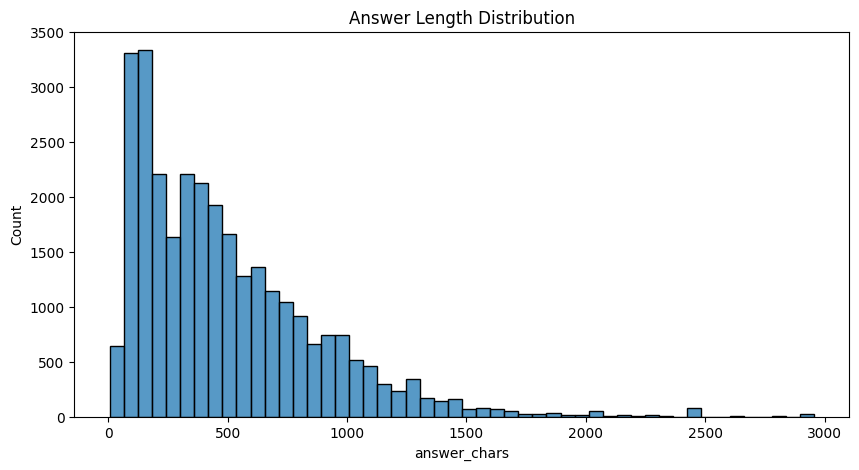

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    train["answer_chars"],
    bins=50
)

plt.title("Answer Length Distribution")
plt.savefig("/content/drive/MyDrive/plots/Answer Length distribution histogram", dpi=300, bbox_inches='tight')
print("saved plot successfully")
plt.show()

In [ ]:
train["answer_words"] = (
    train["output"]
    .astype(str)
    .apply(lambda x: len(x.split()))
)

train.head()

,ID,input,output,subset,question_chars,question_words,answer_chars,answer_words
0,ID_TR_Aka_Gha_A3B1799D,"Ɔkwan bɛn so na mmabunbɛtumi aboa wɔn mfɛfoɔ a nsa anaa nnubɔne ama wɔayɛ wɔn ayayadeɛ? Yei bi ne sɛnea wɔbɛkyekye wɔn werɛ, sɛnea wɔbɛboa wɔn ma wɔanya mmoa firi nnwumakuo a ɛfata hɔ, ne sɛnea wɔbɛsiw afɔbu suban ne nsɛm a nkurɔfoɔ de gu oyarefoɔ no so no kwan.","Mmabun betumi aboa atipɛnfo a ebia nsa anaa nnubɔne ama wɔayɛ wɔn ayayadeɛ so denam: Nkate fam mmoa a wɔde bɛma na wɔagye wɔn nkate atom a wɔremmu atɛn anaasɛ wɔmfa asodi nto wɔn so. Wɔn a wɔbɛhyɛ wɔn nkuran ma wɔakɔhwehwɛ ayaresa na wɔanya mmoa nnwuma te sɛ afotu, telefon a wɔde frɛ nkurɔfo wɔ ɔhaw mu, anaa ahyehyɛde ahorow a wɔkamfo nkurɔfo. Boa a wɔbɛboa wɔn ma wɔafa akwan horow a wɔbɛfa so abɔ amanneɛ, a nea ɛka ho ne sɛ wɔbɛkɔ mmarahyɛ baguafo nkyɛn anaasɛ wɔbɛhwehwɛ mmara kwan so mmoa ...",Aka_Gha,262,50,796,164
1,ID_TR_Aka_Gha_1C80317F,"Edinnsiananmu bɛn na nnipa a ɛsono wɔn bɔbeasu taa de di dwuma, na yɛbɛyɛ dɛn ahwɛ ahu sɛ yɛde redi dwuma yiye?","Wɔ Ghana mu no, amanmmra no gye binary gender nkutoo tom a she/he edinnsiananmu nkutoo na ɛka ho",Aka_Gha,111,22,96,18
2,ID_TR_Aka_Gha_06671AD1,Ɔkwan bɛn so na ɔbarima ne ɔbea nna a wɔtwe wɔn ho fi ho anaa nna mu adwumadi a wɔtwentwɛn so no boa ma asiane so tew?,"Sɛ wɔtwe wɔn ho fi nna mu anaasɛ wɔtwentwɛn wɔn nan ase a, ɛboa ma asiane nso tew denam asiane a ɛwɔ STI ne HIV a ɛbata nna ho a woyi fi hɔ anaasɛ wɔkyɛ so. Sɛ obi twe ne ho fi ho a, ɛkyerɛ sɛ ɔbɛkwati nna mu dwumadi biara, a ɔbarima ne ɔbea nna a ɔde ne ho hyɛ ɔbarima ne ɔbea nna mu, awotwaa mu, ne anom nna ka ho. Sɛ wopaw sɛ wobɛtwe wo ho afi nna ho anaasɛ wobɛtwentwɛn nna mu kosi sɛ wubesiesie wo ho na wo ne ɔhokafo a onni ɔbarima ne ɔbea nna mu yare ne HIV nni ɔyere biako ntam abusuabɔ s...",Aka_Gha,118,27,717,158
3,ID_TR_Aka_Gha_BDD640FB,"Dɛn ne aduru a wodi si nyisɛn ano ntɛm ntɛm, na ɛyɛ adwuma sɛn?","Aduru a wodi si nyisɛn ano ntɛm ntɛm (Emergency contraception (EC)) kyerɛ akwan a wɔfa so siw nyinsɛn ano wɔ nna a wɔammɔ ho ban, nyinsɛn ano a entumi nyɛ adwuma yiye, anaa nna mu ɔbrasɛe akyi. EC yɛ adwuma denam ovulation a esiw ano anaasɛ ɛkyɛ, ɛwo a wɔde mmadwoa nyinsɛn, anaasɛ ɛwo a wɔahyɛ no ma a wɔde hyɛ awotwaa mu, a egyina ɔkwan pɔtee a wɔfa so yɛ ne bere a wɔde ma so.",Aka_Gha,63,14,381,77
4,ID_TR_Aka_Gha_46685257,"Hu sɛnea ɛyɛ den sɛ wubehu bɔbea mu basabasayɔ (GBV) na woayɛ ho biribi, na si hia a ɛho hia sɛ wohwehwɛ mmoa so dua.","Ɛnyɛ mmerɛw bere nyinaa sɛ wubehu bɔbea mu basabasayɔ (GBV), nanso kae sɛ, mmoa a wobɛhwehwɛ no yɛ ahoɔden ho sɛnkyerɛnne, na ɛnyɛ mmerɛwyɛ.",Aka_Gha,117,25,140,24


In [ ]:
train["answer_words"].describe()

,answer_words
count,29815.000000
mean,76.217206
std,58.851291
min,1.000000
25%,30.000000
50%,61.000000
75%,107.000000
max,482.000000


saved plot successfully


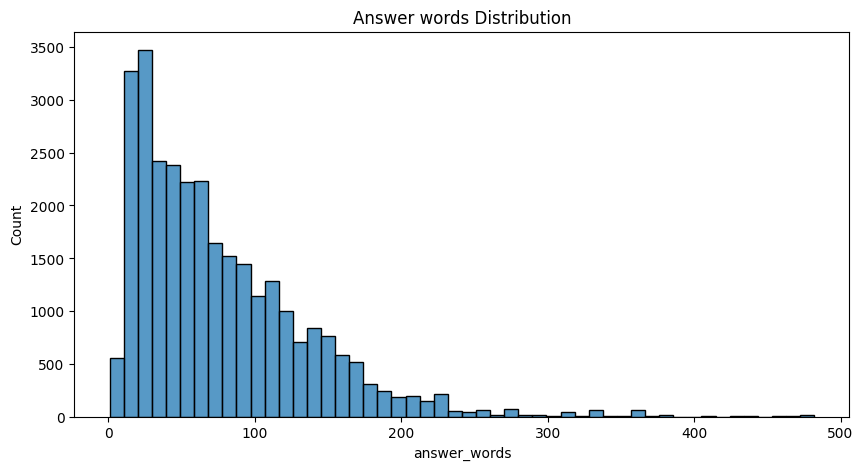

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    train["answer_words"],
    bins=50
)

plt.title("Answer words Distribution")
plt.savefig("/content/drive/MyDrive/plots/Answer words distribution histogram", dpi=300, bbox_inches='tight')
print("saved plot successfully")
plt.show()

# Compare Languages

In [ ]:
train.groupby("subset")["question_words"].mean()

,question_words
subset,
Aka_Gha,28.829181
Amh_Eth,9.521951
Eng_Eth,12.224266
Eng_Gha,20.045240
Eng_Ken,11.444712
Eng_Uga,11.245016
Lug_Uga,10.536210
Swa_Ken,11.234300


In [ ]:
train.groupby("subset")["answer_words"].mean()

,answer_words
subset,
Aka_Gha,105.632323
Amh_Eth,20.231436
Eng_Eth,24.471009
Eng_Gha,75.117713
Eng_Ken,78.699519
Eng_Uga,95.383001
Lug_Uga,79.682530
Swa_Ken,84.291787


saved plot successfully


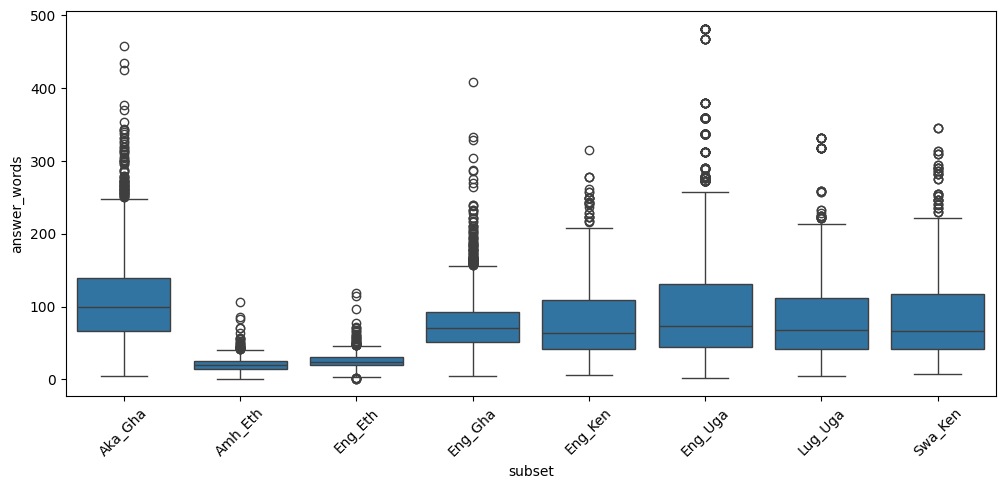

In [ ]:
plt.figure(figsize=(12,5))

sns.boxplot(
    data=train,
    x="subset",
    y="answer_words"
)

plt.xticks(rotation=45)
plt.savefig("/content/drive/MyDrive/plots/Languages comparison plot", dpi=300, bbox_inches='tight')
print("saved plot successfully")
plt.show()

# Duplicate Analysis

In [ ]:
#check for duplicate questions in trian dataset
duplicate_questions = train["input"].duplicated().sum()

print(f"number of dupicated qtns is {duplicate_questions}")

#display all duplicated questions in train dataset
duplicates = train[
    train["input"].duplicated(keep=False)
]

print('lets visualise the duplicated question')
duplicates = duplicates.sort_values("input")

duplicates[["input"]].head(20)

number of dupicated qtns is 1469
lets visualise the duplicated question


,input
7361,A family wants to marry off their 14-year-old daughter because of poverty. What is the best way to advise them?
10156,A family wants to marry off their 14-year-old daughter because of poverty. What is the best way to advise them?
14767,"A friend of mine is struggling with the fear of spreading HIV to other people, how best can I be of help?"
23011,"A friend of mine is struggling with the fear of spreading HIV to other people, how best can I be of help?"
7028,A relative says I should drink a solution of bleach/disinfectant and water to cure the infection in my blood. Is this true?
8349,A relative says I should drink a solution of bleach/disinfectant and water to cure the infection in my blood. Is this true?
9527,A traditional birth attendant told me that drinking a hot lemon tonic right after contact will 'flush out' any sickness. Is this true?
7891,A traditional birth attendant told me that drinking a hot lemon tonic right after contact will 'flush out' any sickness. Is this true?
16776,"After engaging in oral sex and brushing my teeth, is there a risk of contracting HIV/STI?"
14877,"After engaging in oral sex and brushing my teeth, is there a risk of contracting HIV/STI?"


In [ ]:
#display how many times a duplicated question exists
train["input"].value_counts().loc[
    lambda x: x > 1
].head(10)

,count
input,
How is HIV transmitted?,4
Can HIV be cured?,3
What is PEP?,3
Can you describe some of the difficulties faced by those cohabiting with people affected by HIV/AIDS?,3
What are the symptoms of HIV?,3
What is the difference between an STI and an STD?,3
What is PrEP?,3
How is Trichomoniasis treated?,3
What are the symptoms of AIDS?,3


In [ ]:
#check how many uniques answers qupicated questions have
answer_counts = (
    train.groupby("input")["output"]
    .nunique()
)

answer_counts.sort_values(
    ascending=False
).head(20)

,output
input,
How is HIV transmitted?,4
How is Trichomoniasis treated?,3
What are the symptoms of HIV?,3
What is PEP?,3
What is PrEP?,3
Can HIV be cured?,3
What are the symptoms of AIDS?,3
What is the difference between an STI and an STD?,3
Can you describe some of the difficulties faced by those cohabiting with people affected by HIV/AIDS?,3


In [ ]:
#count how many diplucated questions have unique answers more than 1
(answer_counts > 1).sum()

np.int64(1183)

In [ ]:
#show questions that have more than one unique answer
multiple_answers = answer_counts[answer_counts > 1].index

train[train["input"].isin(multiple_answers)] \
    .sort_values("input")

,ID,input,output,subset,question_chars,question_words,answer_chars,answer_words
7361,ID_TR_Eng_Eth_0171F5A7,A family wants to marry off their 14-year-old daughter because of poverty. What is the best way to advise them?,Focus on the long-term economic risk: An educated daughter has a better chance of lifting the family out of poverty later. Marriage at 14 increases health risks and limits her future income.,Eng_Eth,111,20,190,32
10156,ID_TR_Eng_Eth_4D64BB63,A family wants to marry off their 14-year-old daughter because of poverty. What is the best way to advise them?,"This is a question about, Economic/Counseling. Focus on the long-term economic risk: An educated daughter has a better chance of lifting the family out of poverty later. Marriage at 14 increases health risks and limits her future income.",Eng_Eth,111,20,237,38
8349,ID_TR_Eng_Eth_5B249C2A,A relative says I should drink a solution of bleach/disinfectant and water to cure the infection in my blood. Is this true?,"This is a poison. Do not drink it. Drinking bleach or disinfectant can kill you by destroying your stomach, throat, and internal organs. There is no traditional or medical use for this.",Eng_Eth,123,22,185,32
7028,ID_TR_Eng_Eth_1A46D536,A relative says I should drink a solution of bleach/disinfectant and water to cure the infection in my blood. Is this true?,"This is a question about, Harmful Practices/Toxicity. THIS IS A POISON. DO NOT DRINK IT. Drinking bleach or disinfectant can kill you by destroying your stomach, throat, and internal organs. There is no traditional or medical use for this.",Eng_Eth,123,22,239,39
9527,ID_TR_Eng_Eth_41F74651,A traditional birth attendant told me that drinking a hot lemon tonic right after contact will 'flush out' any sickness. Is this true?,"No, this is physically impossible. Pathogens enter cells very quickly, and drinking any liquid cannot reach or ‘flush out’ the infection. Prevention requires condom use, and in emergencies, post-exposure prophylaxis should be used.",Eng_Eth,134,23,231,33
...,...,...,...,...,...,...,...,...
8230,ID_TR_Eng_Eth_591CC524,Will my child with HIV need a special diet that is very expensive?,"No, the child does not need an expensive diet; they simply need a healthy, nutritious diet of local, affordable foods just like any other child.",Eng_Eth,66,13,144,25
14776,ID_TR_Eng_Ken_4F05495E,Will the HIV test hurt?,Not at all. The sample is collected by gently pricking the tip of your fingure. This will not be hurtful as such.,Eng_Ken,23,5,113,22
22840,ID_TR_Eng_Uga_95EEF403,Will the HIV test hurt?,"Not at all; the sample is collected by gently pricking the tip of your finger, and this will not be hurtful as such.",Eng_Uga,23,5,116,23
16297,ID_TR_Eng_Ken_2055ADEC,"Women do not produce sperms, which other ways do they spread HIV apart from kissing?","HIV can be transmitted through various routes of contact, and it is not limited to the exchange of bodily fluids containing sperm. HIV is primarily transmitted through the following routes; Blood Contact, Mother-to-Child Transmission, Transfusion of Infected Blood, Needlestick Injuries, and Organ or Tissue Transplant. It's important to emphasize that both men and women can transmit HIV to each other through sexual contact, and HIV transmission is not solely dependent on the presence of sperm.",Eng_Ken,84,15,498,75


# Leakage Analysis

In [ ]:
#check for overlapping questions in train and val
train_questions = set(
    train["input"].str.lower().str.strip()
)

val_questions = set(
    val["input"].str.lower().str.strip()
)

overlap = train_questions.intersection(val_questions)

print(f"overlapping questions in both train and vai are {len(overlap)}")

overlapping questions in both train and vai are 50


In [ ]:
list(overlap)[:10]

['what are the signs of hpv?',
 'can augmentin treat chlamydia?',
 'if i share a utensil with someone with chlamydia, can i get chlamydia?',
 'if a person receives the antibiotic injection for early syphilis, how quickly is the bacteria killed?',
 'what is syphilis?',
 'how do i test for syphilis in babies?',
 'do they have shots for chlamydia?',
 'when should i get a chlamydia test?',
 'can the sores from herpes look like a simple scratch or rash instead of blisters?',
 'what is the origin of chlamydia?']

In [ ]:
#confirm if questions actually exist in both datasets
question = "what cures gonorrhea?"

print(question in train_questions)
print(question in val_questions)

True
True


In [ ]:
#check for overlapping questions in train and test
test_questions = set(test["input"].str.lower().str.strip())

overlap = train_questions.intersection(
    test_questions
)

print(len(overlap))

15


In [ ]:
list(overlap)[:10]

['how can i explain the concept of safe period (natural family planning) accurately?',
 'what if i feel symptoms for chlamydia after treatment what should i do?',
 'what is the difference between gonorrhea and chlamydia?',
 'can chlamydia be tested in women?',
 'can the parasite that causes trichomoniasis be seen by the naked eye?',
 'can treatment for chlamydia fail?',
 'how does neisseria gonorrhoeae infection manifest?',
 'i had sex yesterday, do i have chlamydia?',
 'what do doctors say about does drinking alcohol kill sti germs?',
 'what is the fastest chlamydia test?']

In [ ]:
#check if same questions repeat across all datasets
question = "what cures gonorrhea?"
question2 = 'can i get chlamydia from oral sex?'
print(question in train_questions)
print(question in val_questions)
print(question in test_questions)

print(question2 in train_questions)
print(question2 in val_questions)
print(question2 in test_questions)

True
True
False
True
False
True


# Semantic Similarity Investigation

In [ ]:
#use similarity embeddings from the sentence transformer model
similarity_model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
#extract a few samples from the train and val datasets to use for our semantic similarity tests
train_sample = train.sample(
    1000,
    random_state=42
)

val_sample = val.sample(
    200,
    random_state=42
)

In [ ]:
#extract the embeddings
train_embeddings = similarity_model.encode(
    train_sample["input"].tolist(),
    show_progress_bar=True
)

val_embeddings = similarity_model.encode(
    val_sample["input"].tolist(),
    show_progress_bar=True
)

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

In [ ]:
#get the cosine similarity of the embeddings
similarities = cosine_similarity(
    val_embeddings,
    train_embeddings
)

#get the maximum similarities
max_similarities = similarities.max(axis=1)

In [ ]:
#print first 20 maximum similarities
max_similarities[:20]

array([0.90838355, 0.77624506, 0.8772092 , 0.8930167 , 0.74380004,
       0.821244  , 0.72095925, 0.9038818 , 1.        , 0.6892514 ,
       0.499524  , 0.90252894, 0.7458688 , 0.7096147 , 0.74376327,
       0.69460994, 0.86718035, 0.5539289 , 0.6666154 , 0.94724166],
      dtype=float32)

In [ ]:
max_similarities.mean()

np.float32(0.78026354)

# Tokenization EDA

In [ ]:
#tokenise our train dataset
tokenizer = AutoTokenizer.from_pretrained(
    "google/mt5-base"
)

train["question_tokens"] = train["input"].apply(
    lambda x: len(
        tokenizer.encode(
            str(x),
            truncation=False
        )
    )
)

train.head()

config.json:   0%|          | 0.00/702 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/376 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/65.0 [00:00<?, ?B/s]

,ID,input,output,subset,question_chars,question_words,answer_chars,answer_words,question_tokens
0,ID_TR_Aka_Gha_A3B1799D,"Ɔkwan bɛn so na mmabunbɛtumi aboa wɔn mfɛfoɔ a nsa anaa nnubɔne ama wɔayɛ wɔn ayayadeɛ? Yei bi ne sɛnea wɔbɛkyekye wɔn werɛ, sɛnea wɔbɛboa wɔn ma wɔanya mmoa firi nnwumakuo a ɛfata hɔ, ne sɛnea wɔbɛsiw afɔbu suban ne nsɛm a nkurɔfoɔ de gu oyarefoɔ no so no kwan.","Mmabun betumi aboa atipɛnfo a ebia nsa anaa nnubɔne ama wɔayɛ wɔn ayayadeɛ so denam: Nkate fam mmoa a wɔde bɛma na wɔagye wɔn nkate atom a wɔremmu atɛn anaasɛ wɔmfa asodi nto wɔn so. Wɔn a wɔbɛhyɛ wɔn nkuran ma wɔakɔhwehwɛ ayaresa na wɔanya mmoa nnwuma te sɛ afotu, telefon a wɔde frɛ nkurɔfo wɔ ɔhaw mu, anaa ahyehyɛde ahorow a wɔkamfo nkurɔfo. Boa a wɔbɛboa wɔn ma wɔafa akwan horow a wɔbɛfa so abɔ amanneɛ, a nea ɛka ho ne sɛ wɔbɛkɔ mmarahyɛ baguafo nkyɛn anaasɛ wɔbɛhwehwɛ mmara kwan so mmoa ...",Aka_Gha,262,50,796,164,137
1,ID_TR_Aka_Gha_1C80317F,"Edinnsiananmu bɛn na nnipa a ɛsono wɔn bɔbeasu taa de di dwuma, na yɛbɛyɛ dɛn ahwɛ ahu sɛ yɛde redi dwuma yiye?","Wɔ Ghana mu no, amanmmra no gye binary gender nkutoo tom a she/he edinnsiananmu nkutoo na ɛka ho",Aka_Gha,111,22,96,18,55
2,ID_TR_Aka_Gha_06671AD1,Ɔkwan bɛn so na ɔbarima ne ɔbea nna a wɔtwe wɔn ho fi ho anaa nna mu adwumadi a wɔtwentwɛn so no boa ma asiane so tew?,"Sɛ wɔtwe wɔn ho fi nna mu anaasɛ wɔtwentwɛn wɔn nan ase a, ɛboa ma asiane nso tew denam asiane a ɛwɔ STI ne HIV a ɛbata nna ho a woyi fi hɔ anaasɛ wɔkyɛ so. Sɛ obi twe ne ho fi ho a, ɛkyerɛ sɛ ɔbɛkwati nna mu dwumadi biara, a ɔbarima ne ɔbea nna a ɔde ne ho hyɛ ɔbarima ne ɔbea nna mu, awotwaa mu, ne anom nna ka ho. Sɛ wopaw sɛ wobɛtwe wo ho afi nna ho anaasɛ wobɛtwentwɛn nna mu kosi sɛ wubesiesie wo ho na wo ne ɔhokafo a onni ɔbarima ne ɔbea nna mu yare ne HIV nni ɔyere biako ntam abusuabɔ s...",Aka_Gha,118,27,717,158,55
3,ID_TR_Aka_Gha_BDD640FB,"Dɛn ne aduru a wodi si nyisɛn ano ntɛm ntɛm, na ɛyɛ adwuma sɛn?","Aduru a wodi si nyisɛn ano ntɛm ntɛm (Emergency contraception (EC)) kyerɛ akwan a wɔfa so siw nyinsɛn ano wɔ nna a wɔammɔ ho ban, nyinsɛn ano a entumi nyɛ adwuma yiye, anaa nna mu ɔbrasɛe akyi. EC yɛ adwuma denam ovulation a esiw ano anaasɛ ɛkyɛ, ɛwo a wɔde mmadwoa nyinsɛn, anaasɛ ɛwo a wɔahyɛ no ma a wɔde hyɛ awotwaa mu, a egyina ɔkwan pɔtee a wɔfa so yɛ ne bere a wɔde ma so.",Aka_Gha,63,14,381,77,35
4,ID_TR_Aka_Gha_46685257,"Hu sɛnea ɛyɛ den sɛ wubehu bɔbea mu basabasayɔ (GBV) na woayɛ ho biribi, na si hia a ɛho hia sɛ wohwehwɛ mmoa so dua.","Ɛnyɛ mmerɛw bere nyinaa sɛ wubehu bɔbea mu basabasayɔ (GBV), nanso kae sɛ, mmoa a wobɛhwehwɛ no yɛ ahoɔden ho sɛnkyerɛnne, na ɛnyɛ mmerɛwyɛ.",Aka_Gha,117,25,140,24,62


In [ ]:
train["question_tokens"].describe()

,question_tokens
count,29815.000000
mean,30.343753
std,20.976583
min,1.000000
25%,17.000000
50%,24.000000
75%,36.000000
max,187.000000


saved plot successfully


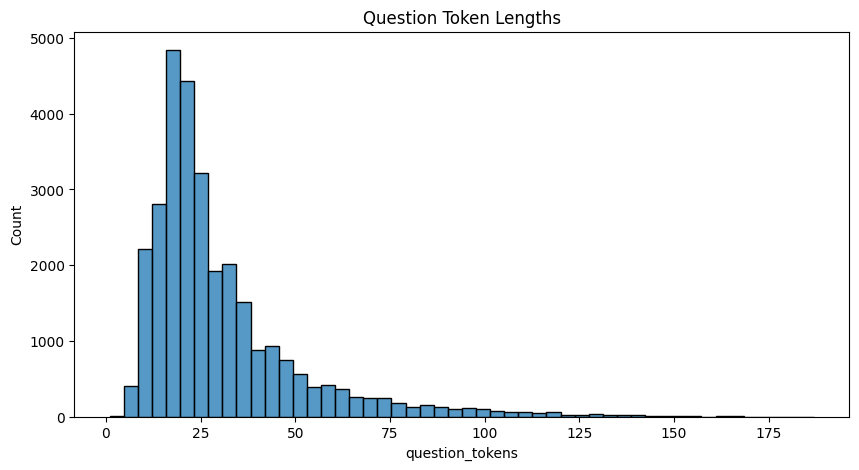

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    train["question_tokens"],
    bins=50
)

plt.title(
    "Question Token Lengths"
)
plt.savefig("/content/drive/MyDrive/plots/Question Token Lengths plot", dpi=300, bbox_inches='tight')
print("saved plot successfully")
plt.show()

In [ ]:
#get answer tokens for every row
train["answer_tokens"] = train["output"].apply(
    lambda x: len(
        tokenizer.encode(
            str(x),
            truncation=False
        )
    )
)
train.head()

,ID,input,output,subset,question_chars,question_words,answer_chars,answer_words,question_tokens,answer_tokens
0,ID_TR_Aka_Gha_A3B1799D,"Ɔkwan bɛn so na mmabunbɛtumi aboa wɔn mfɛfoɔ a nsa anaa nnubɔne ama wɔayɛ wɔn ayayadeɛ? Yei bi ne sɛnea wɔbɛkyekye wɔn werɛ, sɛnea wɔbɛboa wɔn ma wɔanya mmoa firi nnwumakuo a ɛfata hɔ, ne sɛnea wɔbɛsiw afɔbu suban ne nsɛm a nkurɔfoɔ de gu oyarefoɔ no so no kwan.","Mmabun betumi aboa atipɛnfo a ebia nsa anaa nnubɔne ama wɔayɛ wɔn ayayadeɛ so denam: Nkate fam mmoa a wɔde bɛma na wɔagye wɔn nkate atom a wɔremmu atɛn anaasɛ wɔmfa asodi nto wɔn so. Wɔn a wɔbɛhyɛ wɔn nkuran ma wɔakɔhwehwɛ ayaresa na wɔanya mmoa nnwuma te sɛ afotu, telefon a wɔde frɛ nkurɔfo wɔ ɔhaw mu, anaa ahyehyɛde ahorow a wɔkamfo nkurɔfo. Boa a wɔbɛboa wɔn ma wɔafa akwan horow a wɔbɛfa so abɔ amanneɛ, a nea ɛka ho ne sɛ wɔbɛkɔ mmarahyɛ baguafo nkyɛn anaasɛ wɔbɛhwehwɛ mmara kwan so mmoa ...",Aka_Gha,262,50,796,164,137,377
1,ID_TR_Aka_Gha_1C80317F,"Edinnsiananmu bɛn na nnipa a ɛsono wɔn bɔbeasu taa de di dwuma, na yɛbɛyɛ dɛn ahwɛ ahu sɛ yɛde redi dwuma yiye?","Wɔ Ghana mu no, amanmmra no gye binary gender nkutoo tom a she/he edinnsiananmu nkutoo na ɛka ho",Aka_Gha,111,22,96,18,55,38
2,ID_TR_Aka_Gha_06671AD1,Ɔkwan bɛn so na ɔbarima ne ɔbea nna a wɔtwe wɔn ho fi ho anaa nna mu adwumadi a wɔtwentwɛn so no boa ma asiane so tew?,"Sɛ wɔtwe wɔn ho fi nna mu anaasɛ wɔtwentwɛn wɔn nan ase a, ɛboa ma asiane nso tew denam asiane a ɛwɔ STI ne HIV a ɛbata nna ho a woyi fi hɔ anaasɛ wɔkyɛ so. Sɛ obi twe ne ho fi ho a, ɛkyerɛ sɛ ɔbɛkwati nna mu dwumadi biara, a ɔbarima ne ɔbea nna a ɔde ne ho hyɛ ɔbarima ne ɔbea nna mu, awotwaa mu, ne anom nna ka ho. Sɛ wopaw sɛ wobɛtwe wo ho afi nna ho anaasɛ wobɛtwentwɛn nna mu kosi sɛ wubesiesie wo ho na wo ne ɔhokafo a onni ɔbarima ne ɔbea nna mu yare ne HIV nni ɔyere biako ntam abusuabɔ s...",Aka_Gha,118,27,717,158,55,335
3,ID_TR_Aka_Gha_BDD640FB,"Dɛn ne aduru a wodi si nyisɛn ano ntɛm ntɛm, na ɛyɛ adwuma sɛn?","Aduru a wodi si nyisɛn ano ntɛm ntɛm (Emergency contraception (EC)) kyerɛ akwan a wɔfa so siw nyinsɛn ano wɔ nna a wɔammɔ ho ban, nyinsɛn ano a entumi nyɛ adwuma yiye, anaa nna mu ɔbrasɛe akyi. EC yɛ adwuma denam ovulation a esiw ano anaasɛ ɛkyɛ, ɛwo a wɔde mmadwoa nyinsɛn, anaasɛ ɛwo a wɔahyɛ no ma a wɔde hyɛ awotwaa mu, a egyina ɔkwan pɔtee a wɔfa so yɛ ne bere a wɔde ma so.",Aka_Gha,63,14,381,77,35,175
4,ID_TR_Aka_Gha_46685257,"Hu sɛnea ɛyɛ den sɛ wubehu bɔbea mu basabasayɔ (GBV) na woayɛ ho biribi, na si hia a ɛho hia sɛ wohwehwɛ mmoa so dua.","Ɛnyɛ mmerɛw bere nyinaa sɛ wubehu bɔbea mu basabasayɔ (GBV), nanso kae sɛ, mmoa a wobɛhwehwɛ no yɛ ahoɔden ho sɛnkyerɛnne, na ɛnyɛ mmerɛwyɛ.",Aka_Gha,117,25,140,24,62,76


In [ ]:
train["answer_tokens"].describe()

,answer_tokens
count,29815.000000
mean,153.640449
std,125.069602
min,4.000000
25%,60.000000
50%,116.000000
75%,209.000000
max,1079.000000


saved plot successfully


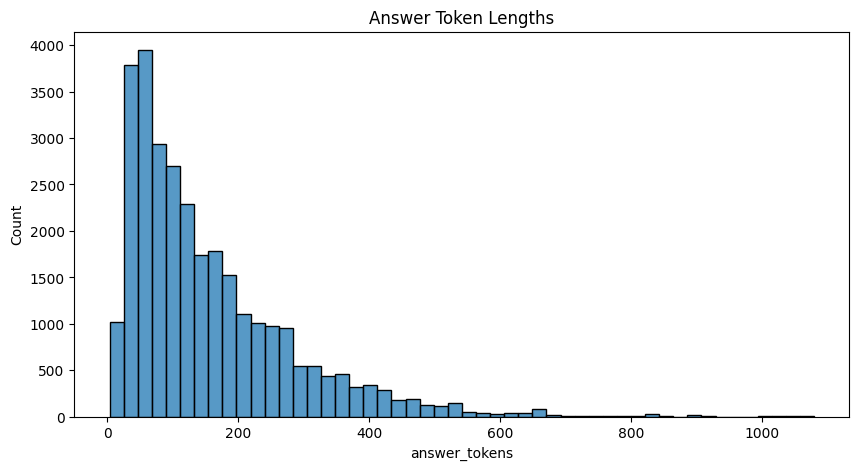

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    train["answer_tokens"],
    bins=50
)

plt.title(
    "Answer Token Lengths"
)
plt.savefig("/content/drive/MyDrive/plots/Answer Token Lengths plot", dpi=300, bbox_inches='tight')
print("saved plot successfully")

plt.show()

In [ ]:
print(np.percentile(
    train["question_tokens"],
    95
))

print(np.percentile(
    train["answer_tokens"],
    95
))

74.0
404.0


In [ ]:
#summary of all our findings in the entire eda
print("EDA SUMMARY")

print("="*50)

print("Train:", train.shape)

print("Languages:")
print(train["subset"].value_counts())

print("Duplicate Questions:",
      train["input"].duplicated().sum())

print("Avg Question Tokens:",
      train["question_tokens"].mean())

print("Avg Answer Tokens:",
      train["answer_tokens"].mean())

print("95% Question Tokens:",
      np.percentile(
          train["question_tokens"],
          95
      ))

print("95% Answer Tokens:",
      np.percentile(
          train["answer_tokens"],
          95
      ))

EDA SUMMARY
Train: (29815, 10)
Languages:
subset
Eng_Uga    7624
Aka_Gha    4455
Eng_Gha    4443
Eng_Eth    3915
Lug_Uga    3383
Eng_Ken    2080
Swa_Ken    2070
Amh_Eth    1845
Name: count, dtype: int64
Duplicate Questions: 1469
Avg Question Tokens: 30.34375314439041
Avg Answer Tokens: 153.64044943820224
95% Question Tokens: 74.0
95% Answer Tokens: 404.0


# Preprocessing

Goals:

1. Remove invalid records
2. Normalize multilingual text
3. Remove exact duplicates
4. Remove train-validation leakage
5. Create clean datasets used by all experiments

In [ ]:
import numpy as np
import re
import unicodedata

from datasets import Dataset

In [ ]:
#text cleaning function
def clean_text(text):

    if pd.isna(text):
        return ""

    text = str(text)

    # Unicode normalization
    text = unicodedata.normalize("NFKC", text)

    # Remove tabs/newlines
    text = text.replace("\n", " ")
    text = text.replace("\t", " ")

    # Collapse spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [ ]:
#apply cleaning
train["input"] = train["input"].apply(clean_text)
train["output"] = train["output"].apply(clean_text)

val["input"] = val["input"].apply(clean_text)
val["output"] = val["output"].apply(clean_text)

test["input"] = test["input"].apply(clean_text)

In [ ]:
#remove empty questions
train = train[
    train["input"].str.strip() != ""
].reset_index(drop=True)

val = val[
    val["input"].str.strip() != ""
].reset_index(drop=True)

In [ ]:
#remove exact dupicate QA pairs
before = len(train)

train = train.drop_duplicates(
    subset=[
        "input",
        "output",
        "subset"
    ]
).reset_index(drop=True)

print(
    "Removed:",
    before - len(train)
)

Removed: 6


In [ ]:
#remove validation leakage
val_questions = set(
    val["input"]
    .str.lower()
    .str.strip()
)

before = len(train)

train = train[
    ~train["input"]
    .str.lower()
    .str.strip()
    .isin(val_questions)
].reset_index(drop=True)

print(
    "Leakage Removed:",
    before - len(train)
)

Leakage Removed: 57


In [ ]:
train.to_csv(
    "/content/drive/MyDrive/datasets/train_clean.csv",
    index=False
)

val.to_csv(
    "/content/drive/MyDrive/datasets/val_clean.csv",
    index=False
)

test.to_csv(
    "/content/drive/MyDrive/datasets/test_clean.csv",
    index=False
)

print("Saved cleaned datasets")

Saved cleaned datasets


# Evaluation Setup

Competition evaluates:

1. ROUGE-1
2. ROUGE-L
3. LLM Judge

In [ ]:
!pip install rouge-score
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(
    ["rouge1", "rougeL"],
    use_stemmer=False
)

  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=0ea680124fcc5596a08c1ed79e0f102d93bfd7e9bd565597f250a5339b9561e6
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score


In [ ]:
#evaluation function
def evaluate_predictions(
    predictions,
    references
):

    rouge1 = []
    rougeL = []

    for pred, ref in zip(
        predictions,
        references
    ):

        scores = scorer.score(
            ref,
            pred
        )

        rouge1.append(
            scores["rouge1"].fmeasure
        )

        rougeL.append(
            scores["rougeL"].fmeasure
        )

    return {
        "ROUGE1": np.mean(rouge1),
        "ROUGEL": np.mean(rougeL)
    }

# Submission Generator

columns required

ID
TargetRLF1
TargetR1F1
TargetLLM

All prediction columns must contain identical answers.

In [ ]:
#submission function
def create_submission(
    ids,
    predictions,
    filename
):

    submission = pd.DataFrame({

        "ID": ids,

        "TargetRLF1": predictions,

        "TargetR1F1": predictions,

        "TargetLLM": predictions
    })

    submission.to_csv(
        filename,
        index=False
    )

    print(
        f"Saved {filename}"
    )

# Experiment 1: Retrieval Baseline

## Objective

Determine how much of the task can be solved using retrieval alone.

## Hypothesis

Since the dataset contains many repeated concepts and duplicate questions,
retrieving the most similar training answer may achieve a reasonable score.

## Method

1. Convert all training questions into embeddings
2. Convert validation questions into embeddings
3. Find the most similar training question
4. Return its answer
5. Evaluate using ROUGE
6. Generate competition submission

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

## Load Clean Data

In [ ]:
train = pd.read_csv("/content/drive/MyDrive/datasets/train_clean.csv")
val = pd.read_csv("/content/drive/MyDrive/datasets/val_clean.csv")
test = pd.read_csv("/content/drive/MyDrive/datasets/test_clean.csv")

## Load Embedding Model

We use a multilingual sentence embedding model.

Why?

Questions exist in:

- English
- Luganda
- Akan
- Swahili
- Amharic

A multilingual embedding model can place semantically similar questions
close together in vector space.

In [ ]:
retrieval_model = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/5.12k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/723 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/402 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

## Generate Training Embeddings

Every training question becomes a numerical vector.

Similar questions should have similar vectors.

In [ ]:
train_questions = train["input"].tolist()

train_embeddings = retrieval_model.encode(
    train_questions,
    show_progress_bar=True,
    batch_size=64,
    convert_to_numpy=True
)

Batches:   0%|          | 0/465 [00:00<?, ?it/s]

## Retrieve Answers For Validation Set

For each validation question:

1. Compute embedding
2. Compare against all train embeddings
3. Find most similar question
4. Return corresponding answer

In [ ]:
val_predictions = []

for question in val["input"]:

    q_embedding = retrieval_model.encode(
        [question],
        convert_to_numpy=True
    )

    similarities = cosine_similarity(
        q_embedding,
        train_embeddings
    )[0]

    best_idx = np.argmax(similarities)

    prediction = train.iloc[best_idx]["output"]

    val_predictions.append(prediction)

## Evaluate Validation Performance

In [ ]:
scores = evaluate_predictions(
    val_predictions,
    val["output"].tolist()
)

print(scores)

{'ROUGE1': np.float64(0.46166524999409886), 'ROUGEL': np.float64(0.3914299358903584)}


## Inspect Example Predictions

Let's manually inspect examples to verify our metrics

In [ ]:
for i in range(5):

    print("="*80)

    print("QUESTION:")
    print(val.iloc[i]["input"])

    print("\nTRUE ANSWER:")
    print(val.iloc[i]["output"][:500])

    print("\nPREDICTED ANSWER:")
    print(val_predictions[i][:500])

    print("\n")

QUESTION:
Sɛn na nwomasua ne adwuma nteteeɛ boa akuo a eye mmabun a wɔ hia neaɛma sokoronko ne ohaw ahorow, atubrafo, anaa wɔn a wɔte beae a ntawantawa wɔ mu?

TRUE ANSWER:
Nhyehyɛeɛ aa ama ne mu so te sɛ senea aborɔfo ka no 'STEM' ne 'vocational training' se ɛbɛ adrɛse mmabun kuokuo ahohia soronko ne ɔhaw. Nea wokaho yɛ: atufrafo a bronni bɛkasɛ 'refugee anaa immigrant' ne wɔn a wɔte beae a ntawantawa wɔ mu.Dwumadie suronko betumi ama kasa mmoa a aborɔfo bɛkasɛ 'language support', 'trauma-informed education', ne amammerɛ nkyerɛkyerɛ ne akwan a yɛbetumi di mmabun ahyɛ adesua ne broni bɛkasɛ 'vocational systems' kɛseɛ no mu. Ebiom, mpɔtɛm nkuokuo ne 'NGOs' a wɔwɔ ap

PREDICTED ANSWER:
Atipɛnfoɔ mmoa nkitahodiɛ, nnwumakuo a wɔkamfo nkurɔfoɔ, ne asetena mu akuo di dwuma titire wɔ tumi a wɔma mmabun ma wɔkasa tia animtiaabuo ne nyiyim, ka wɔn nsɛm, na wɔyɛ tebea a ɛka obiara ho na ɛboa mmabun nyinaa. Atipɛnfoɔ mmoa nkitahodiɛ ma mmabun nya baabi a ahotɔ wɔ sɛ wɔbɛdi nkitaho, akyɛ suahunu, 

## Generate Test Predictions

In [ ]:
test_predictions = []

for question in test["input"]:

    q_embedding = retrieval_model.encode(
        [question],
        convert_to_numpy=True
    )

    similarities = cosine_similarity(
        q_embedding,
        train_embeddings
    )[0]

    best_idx = np.argmax(similarities)

    prediction = train.iloc[best_idx]["output"]

    test_predictions.append(prediction)

## Create Competition Submission

In [ ]:
create_submission(
    ids=test["ID"],
    predictions=test_predictions,
    filename="/content/drive/MyDrive/submission_files/submission_exp1.csv"
)

Saved /content/drive/MyDrive/submission_files/submission_exp1.csv
